In [ ]:
!pip install yfinance -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

Data Preprocessing Pipeline

In [ ]:
def get_sp500_data(ticker="^GSPC", start="2015-01-01", end="2025-12-31"):
    print(f"Downloading historical data for {ticker}...")
    data = yf.download(ticker, start=start, end=end)

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = pd.DataFrame(index=data.index)
    df['Price'] = data['Close']
    df['Daily_Return'] = df['Price'].pct_change()

    # Trend Indicators
    df['MA_Short'] = df['Price'].rolling(window=10).mean()
    df['MA_Long'] = df['Price'].rolling(window=50).mean()

    # Advanced Indicator: Relative Strength Index (RSI)
    delta = df['Price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))

    # Advanced Indicator: Bollinger Bands
    df['BB_Middle'] = df['Price'].rolling(window=20).mean()
    df['BB_Std'] = df['Price'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + (2 * df['BB_Std'])
    df['BB_Lower'] = df['BB_Middle'] - (2 * df['BB_Std'])

    # Momentum Indicator: 20-day cumulative return
    df['Momentum_20'] = df['Price'] / df['Price'].shift(20) - 1

    # Mean-Reversion Indicator: rolling z-score of price vs its 20-day mean
    df['ZScore_20'] = (df['Price'] - df['BB_Middle']) / (df['BB_Std'] + 1e-9)

    df = df.dropna()
    return df

data = get_sp500_data(start="2016-01-01", end="2026-03-01")
split_idx = int(len(data) * 0.7)
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

print(f"Data ready: {len(train_df)} Training days, {len(test_df)} Evaluation days.")

/tmp/ipykernel_598/1553612641.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Data ready: 1752 Training days, 752 Evaluation days.


Environment and Agents Definition: This handles the environment math and establishes five distinct strategy profiles.

In [ ]:
class MarketEnvironment:
    """
    Long/flat trading environment (no shorting): agents observe market
    state and choose to Buy (go long), Sell (exit to cash), or Hold.
    A flat transaction cost is charged whenever a trade actually occurs.
    """

    TRANSACTION_COST = 0.001  # 0.1% per trade, charged on entry and exit

    def __init__(self, df, transaction_cost=TRANSACTION_COST):
        self.df = df.reset_index(drop=True)
        self.transaction_cost = transaction_cost
        self.reset()

    def reset(self):
        self.current_step = 50
        self.total_steps = len(self.df) - 1
        self.position = 0  # 0 = flat (cash), 1 = long
        return self._get_state()

    def _get_state(self):
        row = self.df.iloc[self.current_step]
        trend = 1 if row['MA_Short'] >= row['MA_Long'] else 0

        if row['RSI'] < 30: rsi_sig = 0
        elif row['RSI'] > 70: rsi_sig = 2
        else: rsi_sig = 1

        if row['Price'] < row['BB_Lower']: bb_sig = 0
        elif row['Price'] > row['BB_Upper']: bb_sig = 2
        else: bb_sig = 1

        return (trend, rsi_sig, bb_sig, self.position)

    def step(self, action):
        """
        action: 0 = Hold, 1 = Buy (enter long), 2 = Sell (exit to cash)
        Reward is the realised step return of the agent's portfolio.
        """
        current_return = self.df.iloc[self.current_step]['Daily_Return']
        trade_cost = 0.0

        if action == 1 and self.position == 0:
            self.position = 1
            trade_cost = self.transaction_cost
        elif action == 2 and self.position == 1:
            self.position = 0
            trade_cost = self.transaction_cost

        market_component = current_return if self.position == 1 else 0.0
        reward = market_component - trade_cost

        self.current_step += 1
        done = self.current_step >= self.total_steps
        next_state = self._get_state() if not done else None

        info = {"asset_return": current_return, "trade_cost": trade_cost}
        return next_state, reward, done, info


class HeuristicAgents:
    """
    Heuristic agents return Buy/Sell/Hold as ENTER/EXIT signals on a
    long/flat position. Each method takes the current position so it
    knows whether a signal is actionable.
    """

    @staticmethod
    def random_strategy(position, rng):
        if position == 0:
            return 1 if rng.random() < 0.5 else 0
        else:
            return 2 if rng.random() < 0.5 else 0

    @staticmethod
    def moving_average_strategy(row, position):
        golden = row['MA_Short'] > row['MA_Long']
        if position == 0 and golden:
            return 1
        elif position == 1 and not golden:
            return 2
        return 0

    @staticmethod
    def momentum_strategy(row, position, threshold=0.02):
        """
        Reacts to 20-day cumulative momentum (Momentum_20),
        not a single day's return.
        """
        momentum = row['Momentum_20']
        if position == 0 and momentum > threshold:
            return 1
        elif position == 1 and momentum < -threshold:
            return 2
        return 0

    @staticmethod
    def mean_reversion_strategy(row, position, entry_z=-1.5, exit_z=0.5):
        """
        entry_z: standard deviations below the 20-day mean required
                 before this counts as a genuine oversold signal
        exit_z:  z-score at which the position is closed, once price
                 has meaningfully reverted
        """
        z = row['ZScore_20']
        if position == 0 and z < entry_z:
            return 1
        elif position == 1 and z > exit_z:
            return 2
        return 0


class QLearningAgent:
    def __init__(self, state_space_shape=(2, 3, 3, 2), action_space_size=3,
                 lr=0.05, gamma=0.95, epsilon=1.0, epsilon_decay=0.995):
        self.q_table = np.zeros(state_space_shape + (action_space_size,))
        self.lr, self.gamma, self.epsilon, self.epsilon_decay = lr, gamma, epsilon, epsilon_decay
        self.action_space_size = action_space_size

    def choose_action(self, state, train=True):
        if train and np.random.random() < self.epsilon:
            return np.random.choice(self.action_space_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state, done):
        old_value = self.q_table[state + (action,)]
        next_max = 0 if done else np.max(self.q_table[next_state])
        self.q_table[state + (action,)] = old_value + self.lr * (reward + self.gamma * next_max - old_value)

    def decay_epsilon(self):
        self.epsilon = max(0.01, self.epsilon * self.epsilon_decay)


Training and Backtesting: This cell executes the reinforcement learning phase and backtests all strategies on out-of-sample data split.

In [ ]:
np.random.seed(42)
print("Training Reinforcement Learning Agent...")
env_train = MarketEnvironment(train_df)
rl_agent = QLearningAgent()

for epoch in range(40):
    state = env_train.reset()
    done = False
    while not done:
        action = rl_agent.choose_action(state, train=True)
        next_state, reward, done, _ = env_train.step(action)
        rl_agent.learn(state, action, reward, next_state, done)

        if not done:
            state = next_state

    rl_agent.decay_epsilon()
print("Training Complete!\n")

print("Running Backtest on Out of Sample Test Window...")

agent_names = ["Random", "Moving Average", "Momentum", "Mean Reversion", "Q-Learning (RL)"]
history = {name: [] for name in agent_names}

heuristic_positions = {name: 0 for name in agent_names if name != "Q-Learning (RL)"}
trade_counts = {name: 0 for name in agent_names}

rng = np.random.default_rng(42)  # reproducible random agent

env_test = MarketEnvironment(test_df)
state = env_test.reset()
done = False
idx = env_test.current_step

while not done:
    row = env_test.df.iloc[idx]
    asset_return = row['Daily_Return']

    heuristic_actions = {
        "Random":         HeuristicAgents.random_strategy(heuristic_positions["Random"], rng),
        "Moving Average": HeuristicAgents.moving_average_strategy(row, heuristic_positions["Moving Average"]),
        "Momentum":       HeuristicAgents.momentum_strategy(row, heuristic_positions["Momentum"]),
        "Mean Reversion": HeuristicAgents.mean_reversion_strategy(row, heuristic_positions["Mean Reversion"]),
    }

    for name, act in heuristic_actions.items():
        pos = heuristic_positions[name]
        trade_cost = 0.0
        if act == 1 and pos == 0:
            heuristic_positions[name] = 1
            trade_cost = env_test.transaction_cost
            trade_counts[name] += 1
        elif act == 2 and pos == 1:
            heuristic_positions[name] = 0
            trade_cost = env_test.transaction_cost
            trade_counts[name] += 1

        market_component = asset_return if heuristic_positions[name] == 1 else 0.0
        history[name].append(market_component - trade_cost)

    rl_action = rl_agent.choose_action(state, train=False)
    pos_before = env_test.position
    next_state, reward, done, info = env_test.step(rl_action)
    if pos_before != env_test.position:
        trade_counts["Q-Learning (RL)"] += 1
    history["Q-Learning (RL)"].append(reward)

    if not done:
        state = next_state
    idx += 1

print("Backtest Complete!")
print("\nTrade counts (out-of-sample):")
for name in agent_names:
    print(f"  {name:18s}: {trade_counts[name]} trades")


Training Reinforcement Learning Agent...
Training Complete!

Running Backtest on Out of Sample Test Window...
Backtest Complete!

Trade counts (out-of-sample):
  Random            : 346 trades
  Moving Average    : 18 trades
  Momentum          : 15 trades
  Mean Reversion    : 26 trades
  Q-Learning (RL)   : 29 trades


Advanced Performance Evaluation and Chart Generation: This cell calculates the quantitative metrics and creates an automated performance chart.

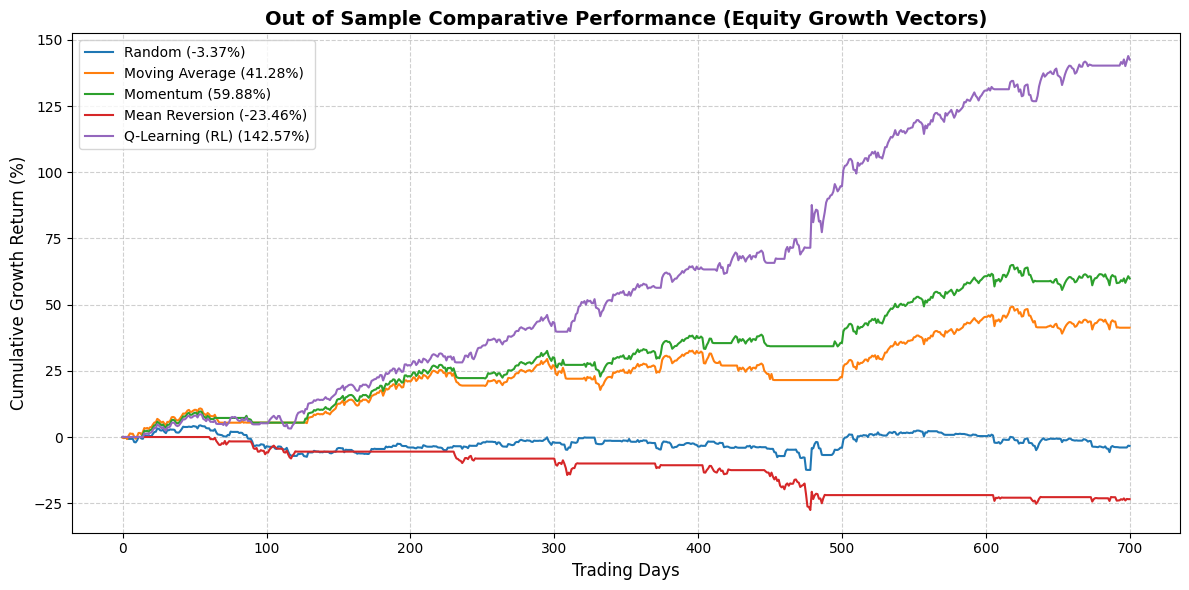


           EXPERIMENTAL METRICS TABLE
                Cumulative Return Annualized Volatility Max Drawdown Sharpe Ratio
Random                     -3.37%                11.08%       16.13%        -0.06
Moving Average             41.28%                10.25%        9.02%         1.26
Momentum                   59.88%                 9.94%        7.32%         1.75
Mean Reversion            -23.46%                11.54%       27.57%        -0.78
Q-Learning (RL)           142.57%                12.34%        5.47%         2.64


In [ ]:
def calculate_metrics(returns):
    returns = np.array(returns)
    cum_returns = np.cumprod(1 + returns) - 1
    total_cum_return = cum_returns[-1] if len(cum_returns) > 0 else 0
    volatility = np.std(returns) * np.sqrt(252)
    sharpe_ratio = (np.mean(returns) * 252) / volatility if volatility != 0 else 0

    peak, max_dd, running_balance = 1.0, 0.0, 1.0
    for r in returns:
        running_balance *= (1 + r)
        if running_balance > peak: peak = running_balance
        dd = (peak - running_balance) / peak
        if dd > max_dd: max_dd = dd

    return {
        "Cumulative Return": f"{total_cum_return * 100:.2f}%",
        "Annualized Volatility": f"{volatility * 100:.2f}%",
        "Max Drawdown": f"{max_dd * 100:.2f}%",
        "Sharpe Ratio": f"{sharpe_ratio:.2f}"
    }, cum_returns

# Calculate results and plot paths
results = {}
plt.figure(figsize=(12, 6))

for agent_name, returns in history.items():
    metrics, cum_path = calculate_metrics(returns)
    results[agent_name] = metrics
    plt.plot(cum_path * 100, label=f"{agent_name} ({metrics['Cumulative Return']})")

plt.title("Out of Sample Comparative Performance (Equity Growth Vectors)", fontsize=14, fontweight='bold')
plt.xlabel("Trading Days", fontsize=12)
plt.ylabel("Cumulative Growth Return (%)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("           EXPERIMENTAL METRICS TABLE")
print("="*50)
print(pd.DataFrame(results).T.to_string())
print("="*50)

Training Log and Grid Search

Executing Hyperparameter Grid Search...
Testing Configuration -> LR: 0.1, Gamma: 0.9
  Out-of-sample: {'Cumulative Return': '76.52%', 'Annualized Volatility': '9.42%', 'Max Drawdown': '7.02%', 'Sharpe Ratio': '2.22'}
Testing Configuration -> LR: 0.05, Gamma: 0.95
  Out-of-sample: {'Cumulative Return': '90.56%', 'Annualized Volatility': '11.37%', 'Max Drawdown': '8.40%', 'Sharpe Ratio': '2.10'}
Testing Configuration -> LR: 0.01, Gamma: 0.99
  Out-of-sample: {'Cumulative Return': '170.30%', 'Annualized Volatility': '12.86%', 'Max Drawdown': '5.47%', 'Sharpe Ratio': '2.85'}


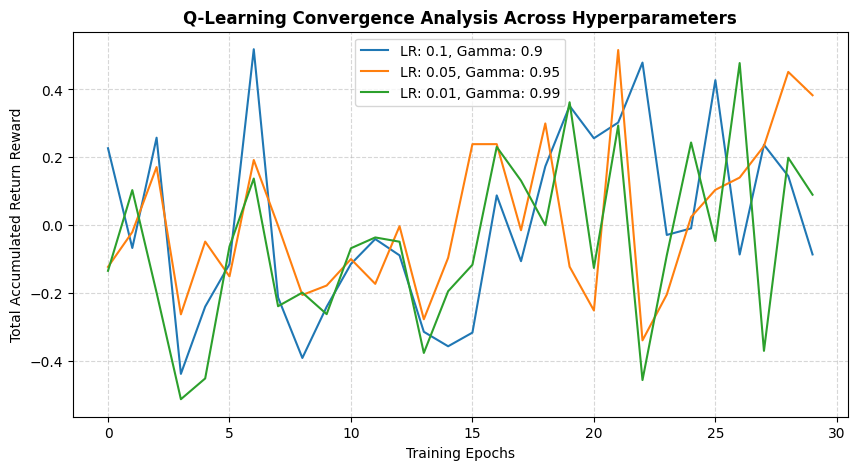


   OUT OF SAMPLE PERFORMANCE BY HYPERPARAMETER CONFIG
                      Cumulative Return Annualized Volatility Max Drawdown Sharpe Ratio
LR: 0.1, Gamma: 0.9              76.52%                 9.42%        7.02%         2.22
LR: 0.05, Gamma: 0.95            90.56%                11.37%        8.40%         2.10
LR: 0.01, Gamma: 0.99           170.30%                12.86%        5.47%         2.85


In [ ]:
def train_and_track_agent(train_df, lr, gamma, epochs=40):
    """
    Trains a Q-learning agent and logs the per-epoch training reward
    (for the convergence plot) alongside the trained agent itself.
    """
    env = MarketEnvironment(train_df)
    agent = QLearningAgent(lr=lr, gamma=gamma, epsilon=1.0)

    epoch_rewards = []

    for epoch in range(epochs):
        state = env.reset()
        done = False
        total_epoch_reward = 0

        while not done:
            action = agent.choose_action(state, train=True)
            next_state, reward, done, _ = env.step(action)
            agent.learn(state, action, reward, next_state, done)

            total_epoch_reward += reward
            if not done:
                state = next_state

        agent.decay_epsilon()
        epoch_rewards.append(total_epoch_reward)

    return agent, epoch_rewards


def evaluate_agent_out_of_sample(agent, eval_df):
    """
    Runs a trained (greedy, train=False) agent over an evaluation
    DataFrame and returns its per-step reward series plus metrics.
    """
    env = MarketEnvironment(eval_df)
    state = env.reset()
    done = False
    returns = []

    while not done:
        action = agent.choose_action(state, train=False)
        next_state, reward, done, _ = env.step(action)
        returns.append(reward)
        if not done:
            state = next_state

    metrics, _ = calculate_metrics(returns)
    return metrics


# Systematic Hyperparameter Grid Search
print("Executing Hyperparameter Grid Search...")
parameter_grid = [
    {"lr": 0.1,  "gamma": 0.90},
    {"lr": 0.05, "gamma": 0.95},
    {"lr": 0.01, "gamma": 0.99},
]

grid_results = {}
grid_oos_metrics = {}

plt.figure(figsize=(10, 5))

for config in parameter_grid:
    config_label = f"LR: {config['lr']}, Gamma: {config['gamma']}"
    print(f"Testing Configuration -> {config_label}")

    trained_agent, rewards = train_and_track_agent(
        train_df, lr=config['lr'], gamma=config['gamma'], epochs=30
    )
    grid_results[config_label] = trained_agent

    oos_metrics = evaluate_agent_out_of_sample(trained_agent, test_df)
    grid_oos_metrics[config_label] = oos_metrics
    print(f"  Out-of-sample: {oos_metrics}")

    plt.plot(rewards, label=config_label)

plt.title("Q-Learning Convergence Analysis Across Hyperparameters", fontsize=12, fontweight='bold')
plt.xlabel("Training Epochs")
plt.ylabel("Total Accumulated Return Reward")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("\n" + "="*60)
print("   OUT OF SAMPLE PERFORMANCE BY HYPERPARAMETER CONFIG")
print("="*60)
print(pd.DataFrame(grid_oos_metrics).T.to_string())
print("="*60)

Time-series Cross-Validation

In [ ]:
def run_time_series_cv(data, folds=3):
    """
    Rolling-window forward-chaining cross-validation to check RL policy
    robustness across different historical periods.
    """
    print(f"Initiating {folds}-Fold Time-Series Cross-Validation...")
    total_samples = len(data)
    fold_size = total_samples // (folds + 1)

    cv_results = {}

    for fold in range(folds):
        print(f"\n--- Processing Fold {fold + 1} ---")

        train_start = 0
        train_end = (fold + 1) * fold_size
        test_end = train_end + fold_size

        cv_train_df = data.iloc[train_start:train_end]
        cv_test_df = data.iloc[train_end:test_end]

        print(f"Train window: {cv_train_df.index[0].strftime('%Y-%m-%d')} to {cv_train_df.index[-1].strftime('%Y-%m-%d')}")
        print(f"Test window:  {cv_test_df.index[0].strftime('%Y-%m-%d')} to {cv_test_df.index[-1].strftime('%Y-%m-%d')}")

        # Train on this fold's training window
        env_train = MarketEnvironment(cv_train_df)
        agent = QLearningAgent(lr=0.05, gamma=0.95)

        for epoch in range(25):
            state = env_train.reset()
            done = False
            while not done:
                action = agent.choose_action(state, train=True)
                next_state, reward, done, _ = env_train.step(action)
                agent.learn(state, action, reward, next_state, done)
                if not done:
                    state = next_state
            agent.decay_epsilon()

        # Evaluate on this fold's held-out window using the same
        # long/flat reward logic as the main environment
        env_test = MarketEnvironment(cv_test_df)
        rl_returns = []
        state = env_test.reset()
        done = False

        while not done:
            action = agent.choose_action(state, train=False)
            next_state, reward, done, _ = env_test.step(action)
            rl_returns.append(reward)
            if not done:
                state = next_state

        metrics, _ = calculate_metrics(rl_returns)
        cv_results[f"Fold {fold + 1}"] = metrics

    print("\n" + "="*50)
    print("        CROSS-VALIDATION ROBUSTNESS MATRIX")
    print("="*50)
    print(pd.DataFrame(cv_results).T.to_string())
    print("="*50)

    return cv_results


# Execute the validation pipeline using the full historical dataset.
cv_results = run_time_series_cv(data, folds=3)

Initiating 3-Fold Time-Series Cross-Validation...

--- Processing Fold 1 ---
Train window: 2016-03-15 to 2018-09-06
Test window:  2018-09-07 to 2021-03-04

--- Processing Fold 2 ---
Train window: 2016-03-15 to 2021-03-04
Test window:  2021-03-05 to 2023-08-29

--- Processing Fold 3 ---
Train window: 2016-03-15 to 2023-08-29
Test window:  2023-08-30 to 2026-02-27

        CROSS-VALIDATION ROBUSTNESS MATRIX
       Cumulative Return Annualized Volatility Max Drawdown Sharpe Ratio
Fold 1           161.29%                20.72%       11.54%         2.14
Fold 2            61.07%                16.99%       12.44%         1.32
Fold 3            86.74%                11.88%        5.12%         2.36


Behavioural Analysis Across Market Regimes: This cell addresses the S&P objective of analysing 'behavioural differences between learning-based and heuristic strategies' and 'robustness across different time periods (e.g. stable vs volatile market conditions)'

Running per-agent behavioural analysis by volatility regime...
(Using the same test_df / rl_agent already trained in cells 6 and onward)


=== RL AGENT REGIME DIAGNOSTIC ===
Position distribution by regime:
regime    position
High Vol  1           271
          0            71
Low Vol   1           324
          0            35

Return stats by regime:
          count     mean      std      min      25%      50%      75%      max
regime                                                                        
High Vol  342.0  0.00167  0.00961 -0.03461 -0.00151  0.00003  0.00569  0.09415
Low Vol   359.0  0.00094  0.00549 -0.01611 -0.00211  0.00025  0.00457  0.01540
=== END DIAGNOSTIC ===

   BEHAVIOURAL DIFFERENCES BY VOLATILITY REGIME (Out-of-Sample Test Window)
          Agent   Regime  Days  Trades  Trades / 100 Days  % Time In Market Cumulative Return Volatility Max Drawdown Sharpe
         Random  Low Vol   359     189               52.6              52.1           -13.09%      7.44%

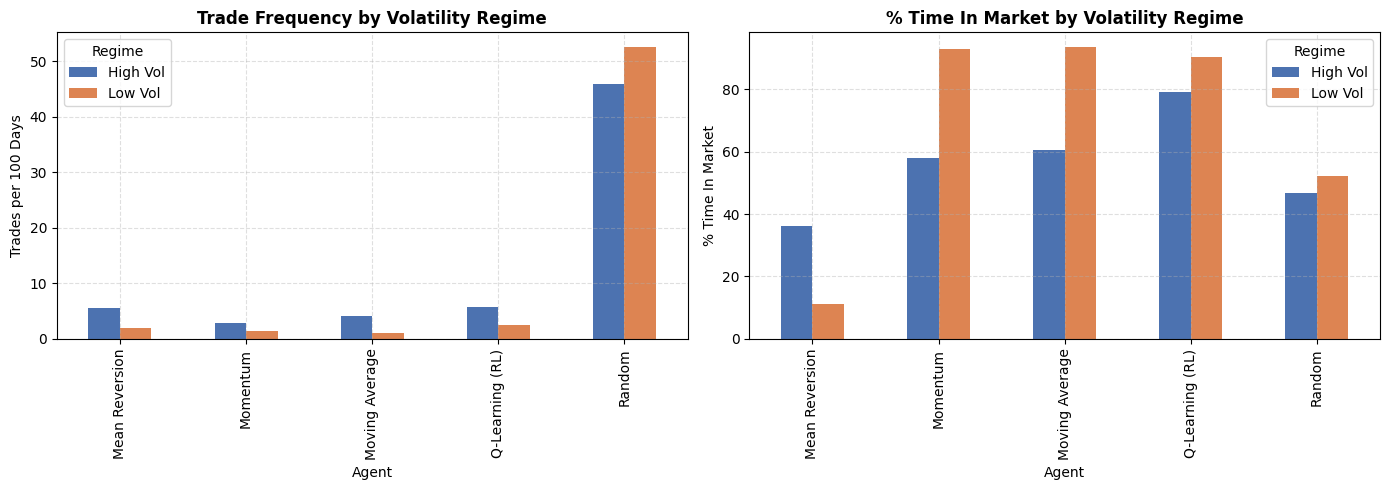

In [ ]:
def classify_volatility_regime(df, window=20):
    """
    Labels each row as 'High Vol' or 'Low Vol' based on whether its
    trailing realised volatility (rolling std of Daily_Return) is above
    or below the median for that period.
    """
    rolling_vol = df['Daily_Return'].rolling(window).std()
    median_vol = rolling_vol.median()
    regime = np.where(rolling_vol >= median_vol, 'High Vol', 'Low Vol')
    return pd.Series(regime, index=df.index, name='Regime')


def run_agent_with_regime_tracking(agent_type, df, rl_agent=None, rng=None):
    """
    Runs a single agent over `df` and returns a per-step record of:
      - action taken
      - position held
      - step return (post transaction cost)
      - volatility regime label

    agent_type: one of "Random", "Moving Average", "Momentum",
                "Mean Reversion", "Q-Learning (RL)"
    For the RL agent, a trained `rl_agent` must be supplied and it is
    run greedily (train=False).
    """
    env = MarketEnvironment(df)
    regime_labels = classify_volatility_regime(df).reset_index(drop=True)

    position = 0
    records = []

    if agent_type == "Q-Learning (RL)":
        state = env.reset()
        done = False
        idx = env.current_step
        while not done:
            action = rl_agent.choose_action(state, train=False)
            pos_before = env.position
            next_state, reward, done, _ = env.step(action)
            records.append({
                "step": idx,
                "action": action,
                "position": env.position,
                "traded": int(pos_before != env.position),
                "return": reward,
                "regime": regime_labels.iloc[idx] if idx < len(regime_labels) else None,
            })
            if not done:
                state = next_state
            idx += 1
    else:
        # Heuristic agents: replicate the same enter/exit logic used in
        # the main backtest, but for a single agent in isolation so it
        # can log its full per-step trajectory.
        env.reset()  # only used to get current_step/total_steps bookkeeping
        for idx in range(env.current_step, env.total_steps):
            row = df.iloc[idx]
            if agent_type == "Random":
                action = HeuristicAgents.random_strategy(position, rng)
            elif agent_type == "Moving Average":
                action = HeuristicAgents.moving_average_strategy(row, position)
            elif agent_type == "Momentum":
                action = HeuristicAgents.momentum_strategy(row, position)
            elif agent_type == "Mean Reversion":
                action = HeuristicAgents.mean_reversion_strategy(row, position)
            else:
                raise ValueError(f"Unknown agent_type: {agent_type}")

            pos_before = position
            trade_cost = 0.0
            if action == 1 and position == 0:
                position = 1
                trade_cost = env.transaction_cost
            elif action == 2 and position == 1:
                position = 0
                trade_cost = env.transaction_cost

            market_component = row['Daily_Return'] if position == 1 else 0.0
            step_return = market_component - trade_cost

            records.append({
                "step": idx,
                "action": action,
                "position": position,
                "traded": int(pos_before != position),
                "return": step_return,
                "regime": regime_labels.iloc[idx] if idx < len(regime_labels) else None,
            })

    return pd.DataFrame(records)


def summarise_behaviour_by_regime(records_df, agent_name):
    """
    Produce a small summary table: trade frequency, time in market,
    and risk/return metrics, broken out by volatility regime.
    """
    rows = []
    for regime in ["Low Vol", "High Vol"]:
        sub = records_df[records_df['regime'] == regime]
        if len(sub) == 0:
            continue
        n_days = len(sub)
        n_trades = sub['traded'].sum()
        pct_time_in_market = sub['position'].mean() * 100
        trades_per_100_days = (n_trades / n_days) * 100 if n_days > 0 else 0

        metrics, _ = calculate_metrics(sub['return'].values)

        rows.append({
            "Agent": agent_name,
            "Regime": regime,
            "Days": n_days,
            "Trades": int(n_trades),
            "Trades / 100 Days": round(trades_per_100_days, 1),
            "% Time In Market": round(pct_time_in_market, 1),
            "Cumulative Return": metrics["Cumulative Return"],
            "Volatility": metrics["Annualized Volatility"],
            "Max Drawdown": metrics["Max Drawdown"],
            "Sharpe": metrics["Sharpe Ratio"],
        })
    return pd.DataFrame(rows)

print("Running per-agent behavioural analysis by volatility regime...")
print("(Using the same test_df / rl_agent already trained in cells 6 and onward)\n")

behaviour_rng = np.random.default_rng(42)  # Same seed as main backtest, for consistency

all_summaries = []
for name in ["Random", "Moving Average", "Momentum", "Mean Reversion"]:
    records = run_agent_with_regime_tracking(name, test_df, rng=behaviour_rng)
    summary = summarise_behaviour_by_regime(records, name)
    all_summaries.append(summary)

rl_records = run_agent_with_regime_tracking("Q-Learning (RL)", test_df, rl_agent=rl_agent)
rl_summary = summarise_behaviour_by_regime(rl_records, "Q-Learning (RL)")
all_summaries.append(rl_summary)

behaviour_table = pd.concat(all_summaries, ignore_index=True)

print("\n=== RL AGENT REGIME DIAGNOSTIC ===")
print("Position distribution by regime:")
print(rl_records.groupby('regime')['position'].value_counts().to_string())
print("\nReturn stats by regime:")
print(rl_records.groupby('regime')['return'].describe().round(5).to_string())
print("=== END DIAGNOSTIC ===\n")

print("="*100)
print("   BEHAVIOURAL DIFFERENCES BY VOLATILITY REGIME (Out-of-Sample Test Window)")
print("="*100)
print(behaviour_table.to_string(index=False))
print("="*100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_trades = behaviour_table.pivot(index="Agent", columns="Regime", values="Trades / 100 Days")
pivot_trades.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Trade Frequency by Volatility Regime", fontweight='bold')
axes[0].set_ylabel("Trades per 100 Days")
axes[0].legend(title="Regime")
axes[0].grid(True, linestyle="--", alpha=0.4)

pivot_time = behaviour_table.pivot(index="Agent", columns="Regime", values="% Time In Market")
pivot_time.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("% Time In Market by Volatility Regime", fontweight='bold')
axes[1].set_ylabel("% Time In Market")
axes[1].legend(title="Regime")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Buy and Hold Benchmark: This is to determine wether the trade genuinely good, or did the underlying market simply rise by a similar amount over the same period. The benchmark is added to the existing metrics table and equity curve chart produced earlier, instead of being reported separately.

Computing Buy and Hold benchmark on the same out of sample window...

   BUY AND HOLD BENCHMARK (Out of Sample Test Window)
  Cumulative Return     : 73.09%
  Annualized Volatility : 14.85%
  Max Drawdown          : 18.90%
  Sharpe Ratio          : 1.31

   UPDATED METRICS TABLE — ALL AGENTS + BENCHMARK
                Cumulative Return Annualized Volatility Max Drawdown Sharpe Ratio
Random                     -3.37%                11.08%       16.13%        -0.06
Moving Average             41.28%                10.25%        9.02%         1.26
Momentum                   59.88%                 9.94%        7.32%         1.75
Mean Reversion            -23.46%                11.54%       27.57%        -0.78
Q-Learning (RL)           142.57%                12.34%        5.47%         2.64
Buy & Hold                 73.09%                14.85%       18.90%         1.31


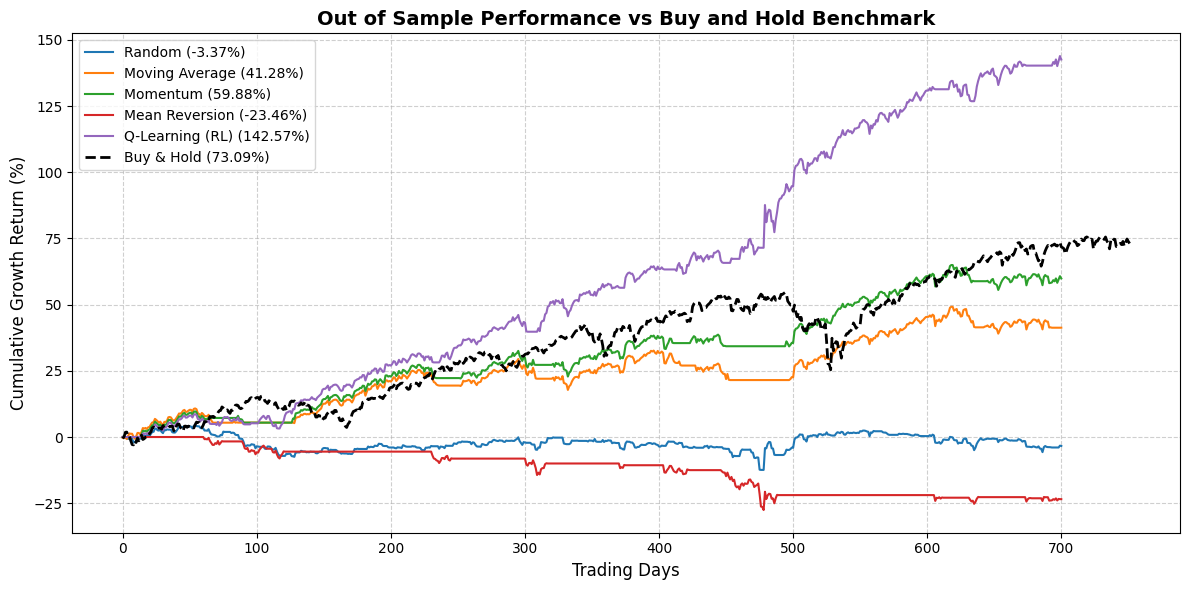

In [ ]:
def run_buy_and_hold(df):
    """
    Passive benchmark: buy on the first tradable day of the window and
    hold to the end, no further trades.
    """
    returns = df['Daily_Return'].values.copy()
    returns = returns.astype(float)
    if len(returns) > 0:
        returns[0] = returns[0] - MarketEnvironment.TRANSACTION_COST
    return returns

print("Computing Buy and Hold benchmark on the same out of sample window...")

bh_returns = run_buy_and_hold(test_df)
bh_metrics, bh_cum_path = calculate_metrics(bh_returns)

print("\n" + "="*60)
print("   BUY AND HOLD BENCHMARK (Out of Sample Test Window)")
print("="*60)
for k, v in bh_metrics.items():
    print(f"  {k:22s}: {v}")
print("="*60)

history["Buy & Hold"] = list(bh_returns)
results["Buy & Hold"] = bh_metrics

print("\n" + "="*60)
print("   UPDATED METRICS TABLE — ALL AGENTS + BENCHMARK")
print("="*60)
print(pd.DataFrame(results).T.to_string())
print("="*60)

plt.figure(figsize=(12, 6))
for agent_name, returns in history.items():
    metrics, cum_path = calculate_metrics(returns)
    style = {"color": "black", "linestyle": "--", "linewidth": 2} if agent_name == "Buy & Hold" else {}
    plt.plot(cum_path * 100, label=f"{agent_name} ({metrics['Cumulative Return']})", **style)

plt.title("Out of Sample Performance vs Buy and Hold Benchmark", fontsize=14, fontweight='bold')
plt.xlabel("Trading Days", fontsize=12)
plt.ylabel("Cumulative Growth Return (%)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Multi-Seed Statistical Robustness: Q-learning training involves epsilon-greedy exploration, which is stochastic. This cell retrains the RL agent across 10 independent seeds and reports results as mean +/- standard deviation rather than a single point estimate, which is necessary to make any claim that the RL agent's performance is a reliable finding rather than an artefact of one run.

Training 10 independently-seeded RL agents for statistical robustness...
  Seed  0: Cum. Return   173.19% | Sharpe   2.87 | Max DD    5.47%
  Seed  1: Cum. Return   144.05% | Sharpe   3.20 | Max DD    5.47%
  Seed  2: Cum. Return    84.70% | Sharpe   2.00 | Max DD   10.75%
  Seed  3: Cum. Return    76.52% | Sharpe   2.22 | Max DD    7.02%
  Seed  4: Cum. Return    90.56% | Sharpe   2.10 | Max DD    8.40%
  Seed  5: Cum. Return   145.17% | Sharpe   2.67 | Max DD    5.47%
  Seed  6: Cum. Return   168.22% | Sharpe   2.82 | Max DD    5.70%
  Seed  7: Cum. Return   170.30% | Sharpe   2.85 | Max DD    5.47%
  Seed  8: Cum. Return   142.57% | Sharpe   2.64 | Max DD    5.47%
  Seed  9: Cum. Return    91.90% | Sharpe   2.65 | Max DD    4.72%

   RL AGENT ROBUSTNESS ACROSS 10 TRAINING SEEDS
      Cumulative Return (%)  Sharpe Ratio  Max Drawdown (%)  Annualized Volatility (%)
mean                 128.72          2.60              6.39                      11.46
std                   38.64       

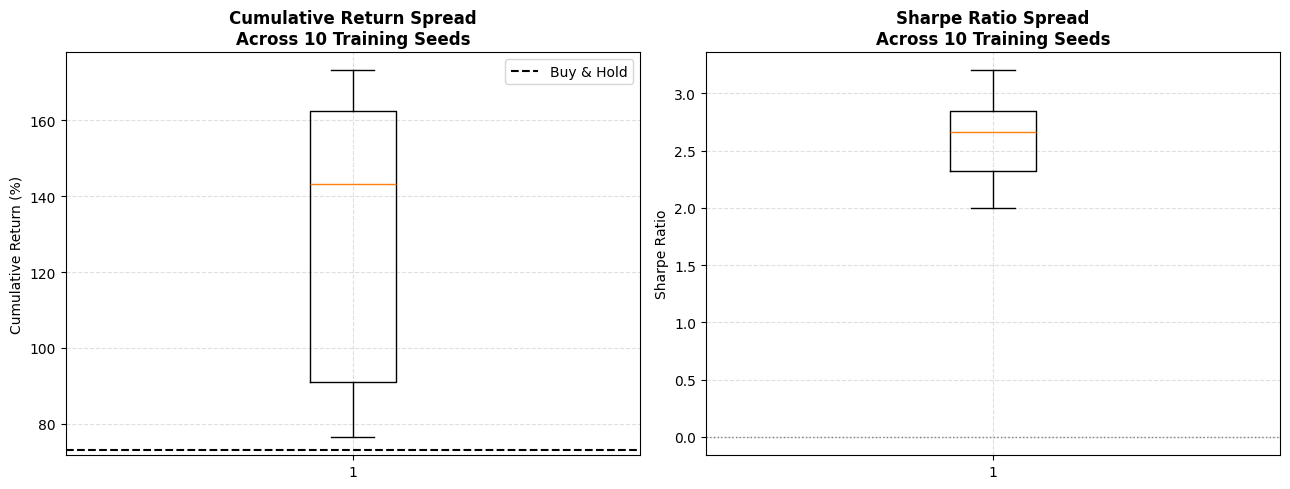

In [ ]:
def train_rl_agent_with_seed(train_df, seed, lr=0.05, gamma=0.95, epochs=40):
    """
    Trains a fresh Q-learning agent with a fixed random seed, so that
    repeated calls with different seeds give genuinely independent
    training runs (instead of all converging to whatever exploration
    path happens to fall out of an unseeded global RNG).
    """
    np.random.seed(seed)
    env = MarketEnvironment(train_df)
    agent = QLearningAgent(lr=lr, gamma=gamma, epsilon=1.0)

    for epoch in range(epochs):
        state = env.reset()
        done = False
        while not done:
            action = agent.choose_action(state, train=True)
            next_state, reward, done, _ = env.step(action)
            agent.learn(state, action, reward, next_state, done)
            if not done:
                state = next_state
        agent.decay_epsilon()

    return agent


def evaluate_rl_agent(agent, eval_df):
    env = MarketEnvironment(eval_df)
    state = env.reset()
    done = False
    returns = []
    while not done:
        action = agent.choose_action(state, train=False)
        next_state, reward, done, _ = env.step(action)
        returns.append(reward)
        if not done:
            state = next_state
    return np.array(returns)

N_SEEDS = 10
seeds = list(range(N_SEEDS))

print(f"Training {N_SEEDS} independently-seeded RL agents for statistical robustness...")

multi_seed_returns = []      # list of full out-of-sample return arrays, one per seed
multi_seed_metrics = []      # list of metrics dicts, one per seed
trained_agents_by_seed = {}  # kept for the policy-consistency analysis later

for seed in seeds:
    agent = train_rl_agent_with_seed(train_df, seed=seed)
    returns = evaluate_rl_agent(agent, test_df)
    metrics, _ = calculate_metrics(returns)

    multi_seed_returns.append(returns)
    multi_seed_metrics.append(metrics)
    trained_agents_by_seed[seed] = agent

    print(f"  Seed {seed:2d}: Cum. Return {metrics['Cumulative Return']:>9s} | "
          f"Sharpe {metrics['Sharpe Ratio']:>6s} | Max DD {metrics['Max Drawdown']:>8s}")


def _parse_pct(s):
    return float(s.strip('%'))

def _parse_float(s):
    return float(s)

cum_returns_pct = [_parse_pct(m['Cumulative Return']) for m in multi_seed_metrics]
sharpes          = [_parse_float(m['Sharpe Ratio']) for m in multi_seed_metrics]
max_dds_pct      = [_parse_pct(m['Max Drawdown']) for m in multi_seed_metrics]
vols_pct         = [_parse_pct(m['Annualized Volatility']) for m in multi_seed_metrics]

summary_stats = pd.DataFrame({
    "Cumulative Return (%)":   cum_returns_pct,
    "Sharpe Ratio":            sharpes,
    "Max Drawdown (%)":        max_dds_pct,
    "Annualized Volatility (%)": vols_pct,
}).agg(['mean', 'std', 'min', 'max']).round(2)

print("\n" + "="*70)
print(f"   RL AGENT ROBUSTNESS ACROSS {N_SEEDS} TRAINING SEEDS")
print("="*70)
print(summary_stats.to_string())
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(cum_returns_pct, vert=True)
axes[0].set_title(f"Cumulative Return Spread\nAcross {N_SEEDS} Training Seeds", fontweight='bold')
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].axhline(_parse_pct(bh_metrics['Cumulative Return']), color='black',
                linestyle='--', label='Buy & Hold')
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].boxplot(sharpes, vert=True)
axes[1].set_title(f"Sharpe Ratio Spread\nAcross {N_SEEDS} Training Seeds", fontweight='bold')
axes[1].set_ylabel("Sharpe Ratio")
axes[1].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Policy Consistency Analysis: Here it determines whether the agents themselves learn similar decision rules — first across the 10 training seeds (same data, different exploration randomness), then across the 3 cross-validation folds (different historical training periods). Comparing agreement in both directions distinguishes 'the agent reliably learns something' from 'the agent happens to converge regardless of training noise' versus 'the policy is fundamentally tied to which period of history it was trained on'.

Computing pairwise policy agreement across the multi-seed RL agents...

Mean pairwise policy agreement (excluding self-comparison): 71.7%
Min pairwise policy agreement: 61.1%
Max pairwise policy agreement: 80.6%


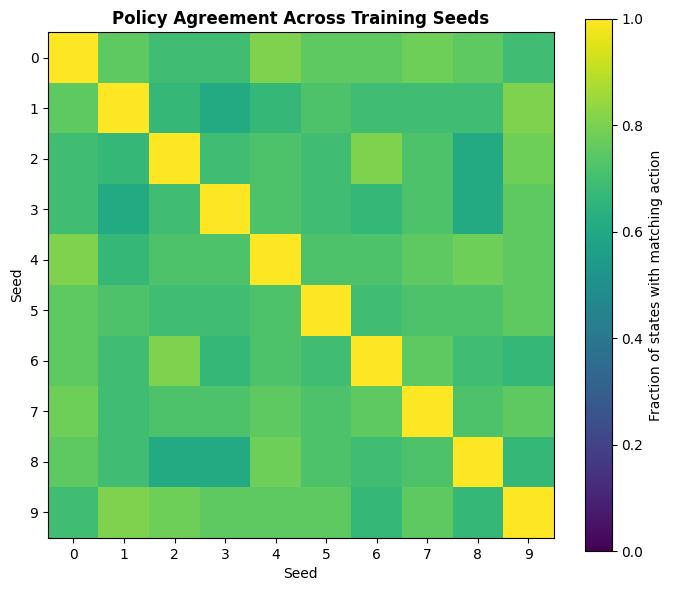


State coverage during training: 27 / 36 possible states visited at least once.
States visited fewer than 10 times (policy for these is less reliable): 12 states

Computing policy agreement across the 3 cross-validation folds...

Policy agreement matrix across CV folds:
        Fold 1  Fold 2  Fold 3
Fold 1    1.00    0.81    0.64
Fold 2    0.81    1.00    0.69
Fold 3    0.64    0.69    1.00

Mean cross-fold policy agreement: 71.3%


In [ ]:
def extract_greedy_policy(agent):
    """
    Collapses a Q-table down to the greedy (argmax) action for every
    state, giving a compact representation of 'what this agent has
    learned to do' that can be directly compared across agents trained
    on different seeds or different historical folds.

    Returns a dict mapping state tuple -> chosen action (int).
    """
    policy = {}
    shape = agent.q_table.shape[:-1]  # exclude the action dimension
    for trend in range(shape[0]):
        for rsi_sig in range(shape[1]):
            for bb_sig in range(shape[2]):
                for position in range(shape[3]):
                    state = (trend, rsi_sig, bb_sig, position)
                    policy[state] = int(np.argmax(agent.q_table[state]))
    return policy


def policy_agreement(policy_a, policy_b):
    """
    Fraction of states where two policies choose the same action.
    1.0 = identical policies, lower values = more disagreement.
    """
    shared_states = set(policy_a.keys()) & set(policy_b.keys())
    if not shared_states:
        return np.nan
    agree = sum(1 for s in shared_states if policy_a[s] == policy_b[s])
    return agree / len(shared_states)

print("Computing pairwise policy agreement across the multi-seed RL agents...")

seed_policies = {seed: extract_greedy_policy(agent) for seed, agent in trained_agents_by_seed.items()}

n = len(seeds)
agreement_matrix = np.zeros((n, n))
for i, seed_i in enumerate(seeds):
    for j, seed_j in enumerate(seeds):
        agreement_matrix[i, j] = policy_agreement(seed_policies[seed_i], seed_policies[seed_j])

off_diagonal = agreement_matrix[~np.eye(n, dtype=bool)]

print(f"\nMean pairwise policy agreement (excluding self-comparison): {off_diagonal.mean():.1%}")
print(f"Min pairwise policy agreement: {off_diagonal.min():.1%}")
print(f"Max pairwise policy agreement: {off_diagonal.max():.1%}")

plt.figure(figsize=(7, 6))
plt.imshow(agreement_matrix, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Fraction of states with matching action")
plt.title("Policy Agreement Across Training Seeds", fontweight='bold')
plt.xlabel("Seed")
plt.ylabel("Seed")
plt.xticks(range(n), seeds)
plt.yticks(range(n), seeds)
plt.tight_layout()
plt.show()

def count_state_visits(train_df):
    """Re-runs a pass over train_df purely to tally how often each
    state tuple is visited, independent of any agent's policy used."""
    env = MarketEnvironment(train_df)
    visit_counts = {}
    state = env.reset()
    done = False
    while not done:
        visit_counts[state] = visit_counts.get(state, 0) + 1
        action = np.random.choice(3)  # visitation only depends on market data, not action
        next_state, _, done, _ = env.step(action)
        if not done:
            state = next_state
    return visit_counts

visit_counts = count_state_visits(train_df)
total_states_possible = 2 * 3 * 3 * 2  # trend x rsi x bb x position
states_visited = len(visit_counts)
print(f"\nState coverage during training: {states_visited} / {total_states_possible} "
      f"possible states visited at least once.")

rarely_visited = {s: c for s, c in visit_counts.items() if c < 10}
if rarely_visited:
    print(f"States visited fewer than 10 times (policy for these is less reliable): "
          f"{len(rarely_visited)} states")


print("\nComputing policy agreement across the 3 cross-validation folds...")

# Retrain one agent per fold (matching the CV cell's training procedure)
# and extract its greedy policy for comparison.
fold_policies = {}
total_samples = len(data)
fold_size = total_samples // (3 + 1)

for fold in range(3):
    train_end = (fold + 1) * fold_size
    cv_train_df = data.iloc[0:train_end]

    np.random.seed(100 + fold)
    fold_agent = train_rl_agent_with_seed(cv_train_df, seed=100 + fold, lr=0.05, gamma=0.95, epochs=25)
    fold_policies[f"Fold {fold + 1}"] = extract_greedy_policy(fold_agent)

fold_names = list(fold_policies.keys())
n_folds = len(fold_names)
fold_agreement_matrix = np.zeros((n_folds, n_folds))
for i, f_i in enumerate(fold_names):
    for j, f_j in enumerate(fold_names):
        fold_agreement_matrix[i, j] = policy_agreement(fold_policies[f_i], fold_policies[f_j])

print("\nPolicy agreement matrix across CV folds:")
print(pd.DataFrame(fold_agreement_matrix, index=fold_names, columns=fold_names).round(2).to_string())

fold_off_diagonal = fold_agreement_matrix[~np.eye(n_folds, dtype=bool)]
print(f"\nMean cross-fold policy agreement: {fold_off_diagonal.mean():.1%}")

Multi-Period Historical Robustness: This cell trains and evaluates every agent independently across four genuinely distinct historical regimes — the 2008 Financial Crisis, a calm post-crisis bull market, the COVID crash and recovery, and the recent AI-driven bull run used as the main test window elsewhere in this notebook. This gives a test of whether any agent's apparent performance is a general property of the strategy or specific to the particular market regime it happened to be evaluated on.

/tmp/ipykernel_598/4132688840.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

   TRAINING AND EVALUATING ALL AGENTS ACROSS DISTINCT HISTORICAL PERIODS

--- 2008 Financial Crisis ---
Full range: 2006-08-10 to 2009-12-30
Train: 2006-08-10 to 2008-12-22 (597 days)
Test:  2008-12-23 to 2009-12-30 (257 days)



/tmp/ipykernel_598/4132688840.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


--- Calm Post-Crisis Bull Market ---
Full range: 2013-03-14 to 2017-12-29
Train: 2013-03-14 to 2016-07-22 (847 days)
Test:  2016-07-25 to 2017-12-29 (363 days)



/tmp/ipykernel_598/4132688840.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


--- COVID Crash & Recovery ---
Full range: 2019-08-12 to 2021-12-30
Train: 2019-08-12 to 2021-04-14 (422 days)
Test:  2021-04-15 to 2021-12-30 (181 days)



/tmp/ipykernel_598/4132688840.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


--- Recent AI Bull Run ---
Full range: 2023-03-15 to 2026-02-27
Train: 2023-03-15 to 2025-04-08 (519 days)
Test:  2025-04-09 to 2026-02-27 (223 days)



   CUMULATIVE RETURN BY AGENT ACROSS HISTORICAL PERIODS
                              Random Moving Average Momentum Mean Reversion Q-Learning (RL) Buy & Hold
2008 Financial Crisis         12.26%         26.49%   49.56%         -1.78%          49.73%     29.10%
Calm Post-Crisis Bull Market  -1.19%         17.25%   21.57%         -4.87%          33.71%     22.80%
COVID Crash & Recovery         1.73%          7.51%    4.93%         -5.12%          13.53%     15.74%
Recent AI Bull Run             0.86%          9.24%   11.80%         -1.96%          24.62%     37.93%

   SHARPE RATIO BY AGENT ACROSS HISTORICAL PERIODS
                             Random Moving Average Momentum Mean Reversion Q-Learning (RL) Buy & Hold
2008 Financial Crisis          0.82           1.57     2.43          -0.24            2.32       1.06
Calm Post-Crisis Bull Market  -0.15           2.13     2.58          -0.84            3.70       1.92
COVID Crash & Recovery         0.42           1.33     1.10          -

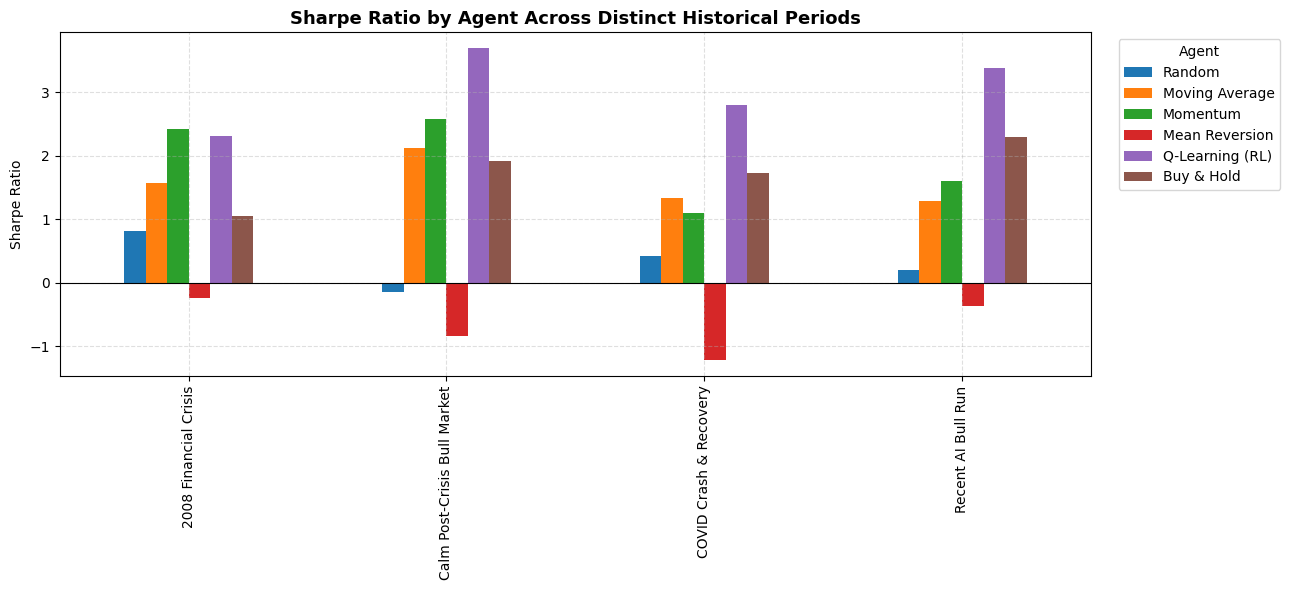


Interpretation notes for Chapter 5/6:
- An agent whose ranking changes substantially between periods (e.g. winning
  during the Calm Bull Market but losing badly during the Financial Crisis) is
  regime-dependent — its earlier reported performance should not be presented
  as a general property of the strategy.
- Compare the RL agent's Sharpe ratio specifically in the Financial Crisis and
  COVID Crash periods against its performance in calmer periods. A learning-based
  agent that degrades sharply in unseen turbulent regimes has not learned a robust
  policy, regardless of how well it performed on the original 2016-2026 window.
- The Buy & Hold benchmark going negative in the Financial Crisis period (if it
  does) is expected and not a bug — it is exactly the scenario where an active
  strategy capable of exiting to cash should be able to add real value over a
  passive position.


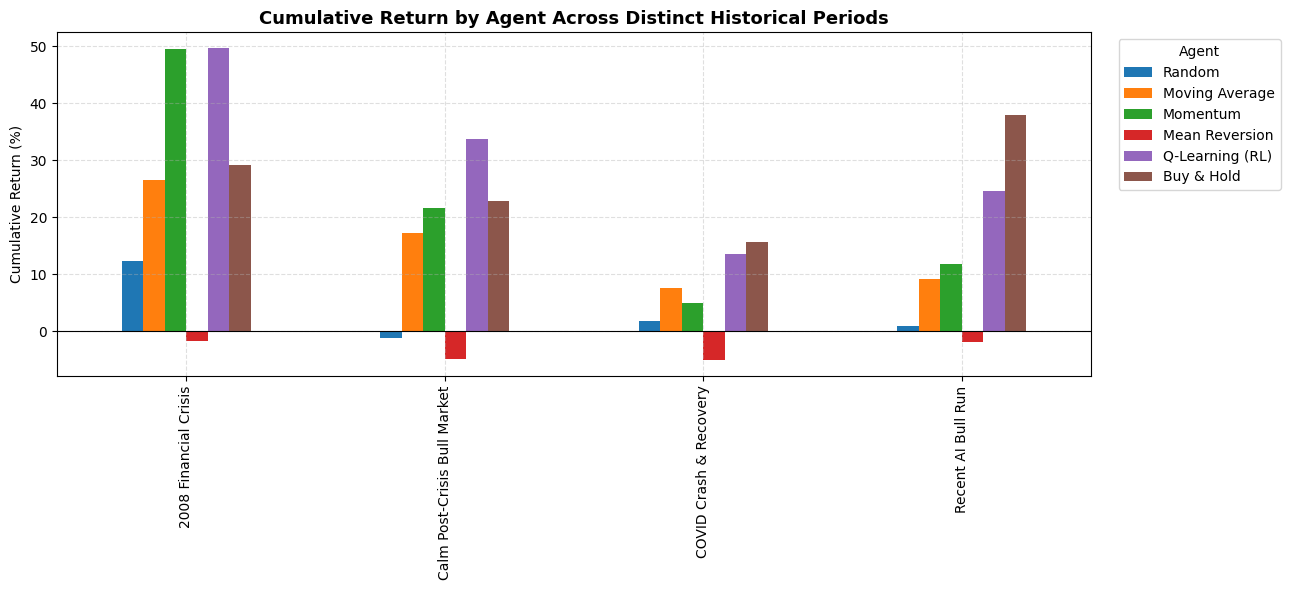

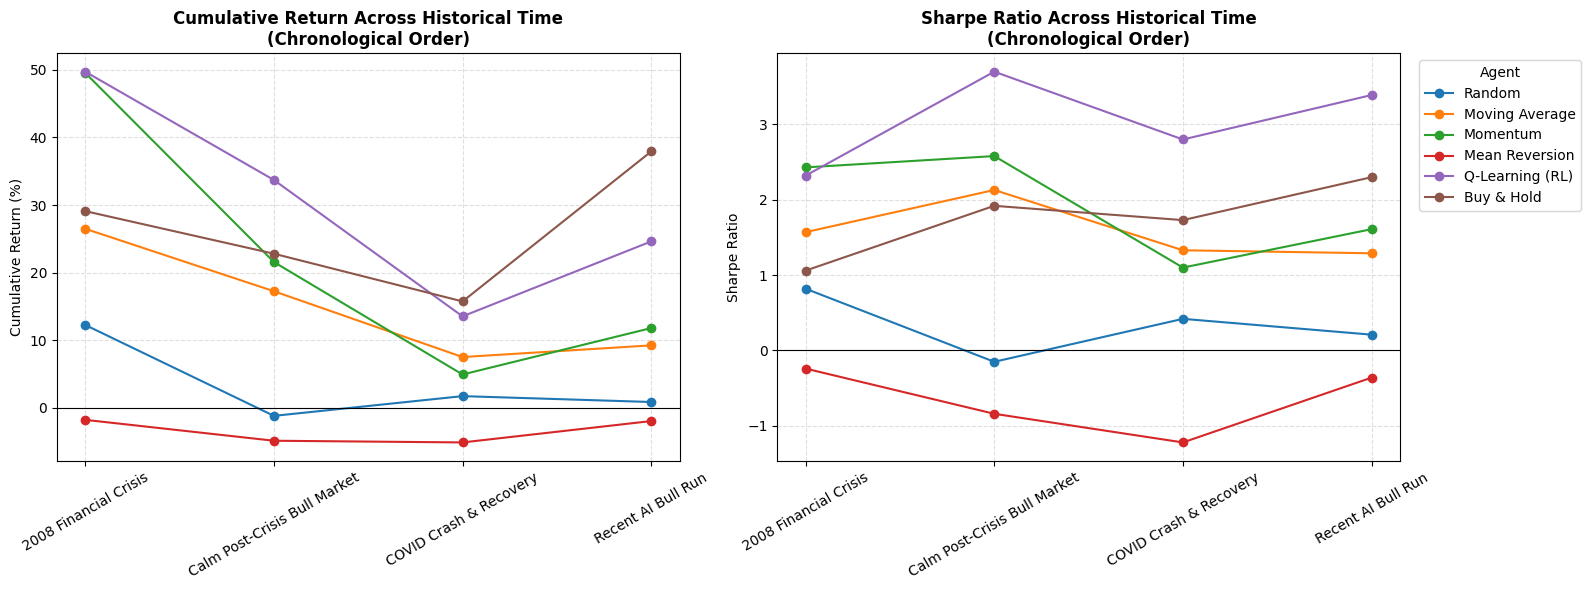


   CROSS-PERIOD STABILITY: MEAN AND STD DEV OF SHARPE RATIO, PER AGENT
                 Mean Sharpe Across Periods  Std Dev of Sharpe Across Periods
Moving Average                         1.58                              0.39
Random                                 0.32                              0.41
Mean Reversion                        -0.66                              0.45
Buy & Hold                             1.75                              0.52
Q-Learning (RL)                        3.05                              0.61
Momentum                               1.93                              0.70

Agents are sorted by std dev (ascending) — Moving Average has the most CONSISTENT Sharpe ratio across distinct historical regimes here, while Momentum has the most variable. A high mean paired with a high std dev (check the table above for which agent this applies to in your actual run) should be described in the dissertation as regime-dependent performance, not as evidence of a

In [ ]:
def get_period_data(ticker="^GSPC", start="2000-01-01", end="2026-03-01"):
    print(f"Downloading data for {start} to {end}...")
    raw = yf.download(ticker, start=start, end=end)

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = pd.DataFrame(index=raw.index)
    df['Price'] = raw['Close']
    df['Daily_Return'] = df['Price'].pct_change()

    df['MA_Short'] = df['Price'].rolling(window=10).mean()
    df['MA_Long'] = df['Price'].rolling(window=50).mean()

    delta = df['Price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))

    df['BB_Middle'] = df['Price'].rolling(window=20).mean()
    df['BB_Std'] = df['Price'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + (2 * df['BB_Std'])
    df['BB_Lower'] = df['BB_Middle'] - (2 * df['BB_Std'])

    # Momentum and z-score columns required by the corrected heuristic
    # strategies (must match get_sp500_data exactly, since this loader
    # is used by the same HeuristicAgents methods).
    df['Momentum_20'] = df['Price'] / df['Price'].shift(20) - 1
    df['ZScore_20'] = (df['Price'] - df['BB_Middle']) / (df['BB_Std'] + 1e-9)

    df = df.dropna()
    return df


def run_all_agents_on_period(period_df, period_name, train_frac=0.7, n_epochs=40):
    split_idx = int(len(period_df) * train_frac)
    period_train = period_df.iloc[:split_idx]
    period_test = period_df.iloc[split_idx:]

    print(f"\n--- {period_name} ---")
    print(f"Full range: {period_df.index[0].date()} to {period_df.index[-1].date()}")
    print(f"Train: {period_train.index[0].date()} to {period_train.index[-1].date()} "
          f"({len(period_train)} days)")
    print(f"Test:  {period_test.index[0].date()} to {period_test.index[-1].date()} "
          f"({len(period_test)} days)")

    if len(period_test) < 30:
        print(f"WARNING: test window for {period_name} is very short ({len(period_test)} days) "
              f"— metrics may be unreliable.")

    # Train RL agent on this period's training split only
    np.random.seed(42)
    env_train = MarketEnvironment(period_train)
    agent = QLearningAgent()
    for epoch in range(n_epochs):
        state = env_train.reset()
        done = False
        while not done:
            action = agent.choose_action(state, train=True)
            next_state, reward, done, _ = env_train.step(action)
            agent.learn(state, action, reward, next_state, done)
            if not done:
                state = next_state
        agent.decay_epsilon()

    # Evaluate RL agent out of sample on this period's test split
    env_test = MarketEnvironment(period_test)
    state = env_test.reset()
    done = False
    rl_returns = []
    while not done:
        action = agent.choose_action(state, train=False)
        next_state, reward, done, _ = env_test.step(action)
        rl_returns.append(reward)
        if not done:
            state = next_state
    rl_returns = np.array(rl_returns)

    period_metrics = {}
    m, _ = calculate_metrics(rl_returns)
    period_metrics["Q-Learning (RL)"] = m

    # Run each heuristic agent independently on this period's test split
    period_rng = np.random.default_rng(42)
    heuristic_fns = {
        "Random":         lambda row, pos: HeuristicAgents.random_strategy(pos, period_rng),
        "Moving Average": HeuristicAgents.moving_average_strategy,
        "Momentum":       HeuristicAgents.momentum_strategy,
        "Mean Reversion": HeuristicAgents.mean_reversion_strategy,
    }

    env_for_cost = MarketEnvironment(period_test)
    for name, fn in heuristic_fns.items():
        position = 0
        returns = []
        for idx in range(env_for_cost.current_step, env_for_cost.total_steps):
            row = period_test.iloc[idx]
            action = fn(row, position)
            trade_cost = 0.0
            if action == 1 and position == 0:
                position = 1
                trade_cost = env_for_cost.transaction_cost
            elif action == 2 and position == 1:
                position = 0
                trade_cost = env_for_cost.transaction_cost
            market_component = row['Daily_Return'] if position == 1 else 0.0
            returns.append(market_component - trade_cost)
        m, _ = calculate_metrics(np.array(returns))
        period_metrics[name] = m

    # Buy and hold benchmark for this period
    bh_returns = period_test['Daily_Return'].values.astype(float).copy()
    if len(bh_returns) > 0:
        bh_returns[0] -= MarketEnvironment.TRANSACTION_COST
    m, _ = calculate_metrics(bh_returns)
    period_metrics["Buy & Hold"] = m

    return period_metrics

historical_periods = {
    "2008 Financial Crisis":        ("2006-06-01", "2009-12-31"),
    "Calm Post-Crisis Bull Market": ("2013-01-01", "2017-12-31"),
    "COVID Crash & Recovery":       ("2019-06-01", "2021-12-31"),
    "Recent AI Bull Run":           ("2023-01-01", "2026-03-01"),
}

print("="*70)
print("   TRAINING AND EVALUATING ALL AGENTS ACROSS DISTINCT HISTORICAL PERIODS")
print("="*70)

period_results = {}
for period_name, (start, end) in historical_periods.items():
    period_df = get_period_data(start=start, end=end)
    period_results[period_name] = run_all_agents_on_period(period_df, period_name)

agent_names_list = ["Random", "Moving Average", "Momentum", "Mean Reversion", "Q-Learning (RL)", "Buy & Hold"]

comparison_rows = {}
for period_name, metrics_dict in period_results.items():
    comparison_rows[period_name] = {
        agent: metrics_dict[agent]["Cumulative Return"] for agent in agent_names_list
    }

comparison_df = pd.DataFrame(comparison_rows).T
comparison_df = comparison_df[agent_names_list]

print("\n" + "="*90)
print("   CUMULATIVE RETURN BY AGENT ACROSS HISTORICAL PERIODS")
print("="*90)
print(comparison_df.to_string())
print("="*90)

sharpe_rows = {}
for period_name, metrics_dict in period_results.items():
    sharpe_rows[period_name] = {
        agent: metrics_dict[agent]["Sharpe Ratio"] for agent in agent_names_list
    }
sharpe_df = pd.DataFrame(sharpe_rows).T
sharpe_df = sharpe_df[agent_names_list]

print("\n" + "="*90)
print("   SHARPE RATIO BY AGENT ACROSS HISTORICAL PERIODS")
print("="*90)
print(sharpe_df.to_string())
print("="*90)

sharpe_plot_df = sharpe_df.apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(13, 6))
sharpe_plot_df.plot(kind="bar", ax=ax)
ax.set_title("Sharpe Ratio by Agent Across Distinct Historical Periods", fontsize=13, fontweight='bold')
ax.set_ylabel("Sharpe Ratio")
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(
    "\nInterpretation notes for Chapter 5/6:\n"
    "- An agent whose ranking changes substantially between periods (e.g. winning\n"
    "  during the Calm Bull Market but losing badly during the Financial Crisis) is\n"
    "  regime-dependent — its earlier reported performance should not be presented\n"
    "  as a general property of the strategy.\n"
    "- Compare the RL agent's Sharpe ratio specifically in the Financial Crisis and\n"
    "  COVID Crash periods against its performance in calmer periods. A learning-based\n"
    "  agent that degrades sharply in unseen turbulent regimes has not learned a robust\n"
    "  policy, regardless of how well it performed on the original 2016-2026 window.\n"
    "- The Buy & Hold benchmark going negative in the Financial Crisis period (if it\n"
    "  does) is expected and not a bug — it is exactly the scenario where an active\n"
    "  strategy capable of exiting to cash should be able to add real value over a\n"
    "  passive position."
)


# Cumulative Return: Grouped Bar Chart (mirrors the Sharpe bar chart above) ---
# Cumulative Return is stored as percentage strings (e.g. "9.21%") by
# calculate_metrics.
comparison_plot_df = comparison_df.apply(
    lambda col: col.astype(str).str.rstrip('%').astype(float)
)

fig, ax = plt.subplots(figsize=(13, 6))
comparison_plot_df.plot(kind="bar", ax=ax)
ax.set_title("Cumulative Return by Agent Across Distinct Historical Periods", fontsize=13, fontweight='bold')
ax.set_ylabel("Cumulative Return (%)")
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Chronological Line Charts
chronological_order = list(historical_periods.keys())
comparison_plot_df_chrono = comparison_plot_df.reindex(chronological_order)
sharpe_plot_df_chrono = sharpe_plot_df.reindex(chronological_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for agent in agent_names_list:
    axes[0].plot(chronological_order, comparison_plot_df_chrono[agent], marker='o', label=agent)
axes[0].set_title("Cumulative Return Across Historical Time\n(Chronological Order)", fontweight='bold')
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle="--", alpha=0.4)

for agent in agent_names_list:
    axes[1].plot(chronological_order, sharpe_plot_df_chrono[agent], marker='o', label=agent)
axes[1].set_title("Sharpe Ratio Across Historical Time\n(Chronological Order)", fontweight='bold')
axes[1].set_ylabel("Sharpe Ratio")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend(title="Agent", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

stability_summary = pd.DataFrame({
    "Mean Sharpe Across Periods": sharpe_plot_df_chrono.mean(),
    "Std Dev of Sharpe Across Periods": sharpe_plot_df_chrono.std(),
}).round(2)
stability_summary = stability_summary.sort_values("Std Dev of Sharpe Across Periods")

print("\n" + "="*70)
print("   CROSS-PERIOD STABILITY: MEAN AND STD DEV OF SHARPE RATIO, PER AGENT")
print("="*70)
print(stability_summary.to_string())
print("="*70)
most_variable_agent = stability_summary["Std Dev of Sharpe Across Periods"].idxmax()
most_stable_agent = stability_summary["Std Dev of Sharpe Across Periods"].idxmin()

print(
    f"\nAgents are sorted by std dev (ascending) — {most_stable_agent} has the most "
    f"CONSISTENT Sharpe ratio across distinct historical regimes here, while "
    f"{most_variable_agent} has the most variable. A high mean paired with a high "
    f"std dev (check the table above for which agent this applies to in your "
    f"actual run) should be described in the dissertation as regime-dependent "
    f"performance, not as evidence of a generally superior strategy."
)

Statistical Significance Testing: This cell tests whether the differences in agent performance reported above are statistically meaningful or could plausibly arise from chance.

In [ ]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

def cliffs_delta(x, y):
    """
    Cliff's delta: a non-parametric effect size measuring how often
    values in x exceed values in y, versus how often the reverse holds.
    Ranges from -1 (every y > every x) to +1 (every x > every y), with
    0 meaning no systematic difference. Unlike a p-value, this doesn't
    shrink just because you have a large sample — it tells you whether
    a difference is actually large in practical terms, which matters
    here since some of our return series have very different lengths.
    """
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    more = sum(xi > yi for xi in x for yi in y)
    less = sum(xi < yi for xi in x for yi in y)
    return (more - less) / (n_x * n_y)


def cliffs_delta_magnitude(delta):
    d = abs(delta)
    if d < 0.147: return "negligible"
    elif d < 0.33: return "small"
    elif d < 0.474: return "medium"
    else: return "large"

print("="*70)
print("   STEP 1: KRUSKAL-WALLIS TEST ACROSS ALL AGENTS")
print("="*70)

agent_return_series = {name: np.array(returns) for name, returns in history.items()}
kw_stat, kw_p = kruskal(*agent_return_series.values())

print(f"H-statistic: {kw_stat:.4f}")
print(f"p-value:     {kw_p:.6f}")
if kw_p < 0.05:
    print("Result: significant (p < 0.05) — at least one agent's return distribution")
    print("differs from the others. Proceeding to pairwise comparisons.")
else:
    print("Result: NOT significant (p >= 0.05) — no strong evidence that any agent's")
    print("returns differ from the others as a group. Pairwise comparisons below should")
    print("be read with this in mind: Bonferroni correction make it stricter still to")
    print("find significance, so we would not expect many (if any) pairs to pass.")


# Pairwise Mann-Whitney U with Bonferroni correction
print("\n" + "="*70)
print("   STEP 2: PAIRWISE MANN-WHITNEY U TESTS (BONFERRONI-CORRECTED)")
print("="*70)

agent_pairs = list(combinations(agent_return_series.keys(), 2))
n_comparisons = len(agent_pairs)
bonferroni_alpha = 0.05 / n_comparisons

print(f"Number of pairwise comparisons: {n_comparisons}")
print(f"Bonferroni-corrected significance threshold: {bonferroni_alpha:.6f} "
      f"(standard 0.05 / {n_comparisons})\n")

pairwise_results = []
for agent_a, agent_b in agent_pairs:
    returns_a = agent_return_series[agent_a]
    returns_b = agent_return_series[agent_b]

    u_stat, p_value = mannwhitneyu(returns_a, returns_b, alternative='two-sided')
    delta = cliffs_delta(returns_a, returns_b)
    magnitude = cliffs_delta_magnitude(delta)
    significant = p_value < bonferroni_alpha

    pairwise_results.append({
        "Agent A": agent_a,
        "Agent B": agent_b,
        "U Statistic": round(u_stat, 1),
        "p-value": round(p_value, 6),
        "Significant (Bonferroni)": "Yes" if significant else "No",
        "Cliffs Delta": round(delta, 3),
        "Effect Size": magnitude,
    })

pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df = pairwise_df.sort_values("p-value")

print(pairwise_df.to_string(index=False))
print("="*70)

significant_pairs = pairwise_df[pairwise_df["Significant (Bonferroni)"] == "Yes"]
print(f"\n{len(significant_pairs)} of {n_comparisons} pairs remain significant after "
      f"Bonferroni correction.")
if len(significant_pairs) > 0:
    print("\nSignificant pairs:")
    for _, row in significant_pairs.iterrows():
        print(f"  {row['Agent A']} vs {row['Agent B']}: "
              f"p={row['p-value']:.6f}, Cliffs delta={row['Cliffs Delta']} ({row['Effect Size']})")

   STEP 1: KRUSKAL-WALLIS TEST ACROSS ALL AGENTS
H-statistic: 51.7019
p-value:     0.000000
Result: significant (p < 0.05) — at least one agent's return distribution
differs from the others. Proceeding to pairwise comparisons.

   STEP 2: PAIRWISE MANN-WHITNEY U TESTS (BONFERRONI-CORRECTED)
Number of pairwise comparisons: 15
Bonferroni-corrected significance threshold: 0.003333 (standard 0.05 / 15)

        Agent A         Agent B  U Statistic  p-value Significant (Bonferroni)  Cliffs Delta Effect Size
         Random Q-Learning (RL)     205443.0 0.000000                      Yes        -0.164       small
 Mean Reversion Q-Learning (RL)     209886.0 0.000001                      Yes        -0.146  negligible
         Random  Mean Reversion     213001.5 0.000004                      Yes        -0.133  negligible
         Random        Momentum     211430.0 0.000005                      Yes        -0.139  negligible
 Mean Reversion      Buy & Hold     230146.5 0.000018                   